100%|██████████| 170M/170M [00:13<00:00, 12.6MB/s]


Epoch 01 | Train Acc: 38.09% | Val Acc: 51.26% | Loss: 1.6922
Epoch 02 | Train Acc: 54.87% | Val Acc: 60.94% | Loss: 1.2533
Epoch 03 | Train Acc: 62.09% | Val Acc: 62.78% | Loss: 1.0610
Epoch 04 | Train Acc: 67.01% | Val Acc: 69.67% | Loss: 0.9439
Epoch 05 | Train Acc: 70.38% | Val Acc: 70.57% | Loss: 0.8564
Epoch 06 | Train Acc: 72.94% | Val Acc: 72.22% | Loss: 0.7895
Epoch 07 | Train Acc: 75.28% | Val Acc: 77.92% | Loss: 0.7277
Epoch 08 | Train Acc: 76.67% | Val Acc: 76.78% | Loss: 0.6824
Epoch 09 | Train Acc: 78.21% | Val Acc: 74.64% | Loss: 0.6439
Epoch 10 | Train Acc: 79.61% | Val Acc: 79.83% | Loss: 0.6054
Epoch 11 | Train Acc: 80.94% | Val Acc: 80.93% | Loss: 0.5654
Epoch 12 | Train Acc: 82.21% | Val Acc: 83.24% | Loss: 0.5369
Epoch 13 | Train Acc: 83.02% | Val Acc: 83.29% | Loss: 0.5122
Epoch 14 | Train Acc: 83.79% | Val Acc: 83.16% | Loss: 0.4884
Epoch 15 | Train Acc: 84.48% | Val Acc: 83.48% | Loss: 0.4665
Epoch 16 | Train Acc: 85.10% | Val Acc: 84.19% | Loss: 0.4499
Epoch 17

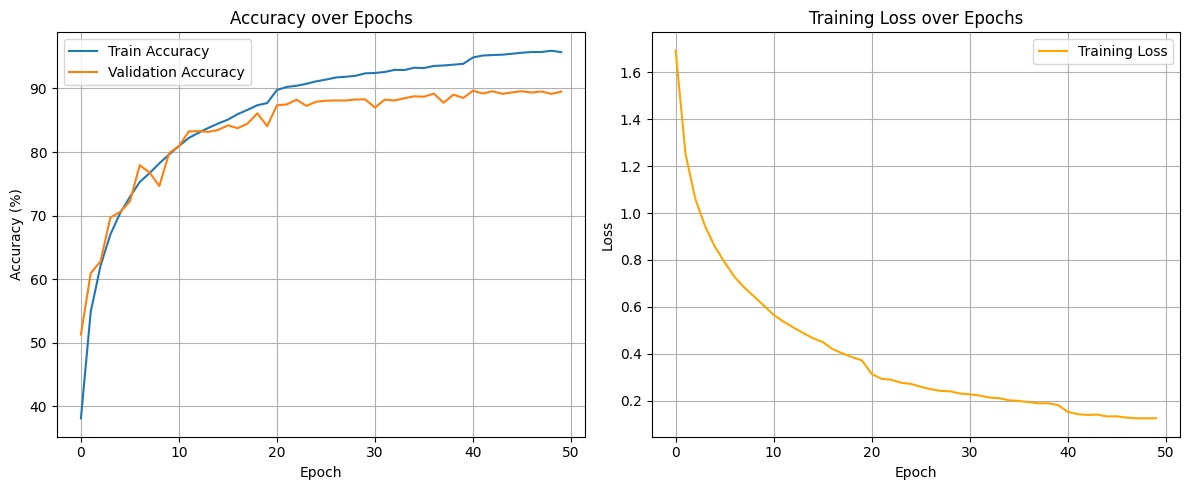

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Data transforms (standard CIFAR-10 normalization)
transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

# Load dataset
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

# CNN architecture
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),  # Output: 32x32x64
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),  # Output: 32x32x64
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # Output: 16x16x64

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # Output: 8x8x128

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # Output: 4x4x256

            nn.Flatten(),
            nn.Linear(4*4*256, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.model(x)

# Initialize model
model = CNN().to(device)

# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

# Track metrics
train_acc_list, val_acc_list, loss_list = [], [], []

# Evaluation function
def evaluate_model():
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total

# Training loop
def train_model(epochs=50):
    for epoch in range(epochs):
        model.train()
        correct, total, total_loss = 0, 0, 0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            total_loss += loss.item()

        scheduler.step()
        train_acc = 100. * correct / total
        val_acc = evaluate_model()
        avg_loss = total_loss / len(trainloader)

        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)
        loss_list.append(avg_loss)

        print(f"Epoch {epoch+1:02} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Loss: {avg_loss:.4f}")

# Train the model
start = time.time()
train_model(epochs=50)
print(f"Training Time: {(time.time() - start):.2f} seconds")

# Final test accuracy
print("Final Test Accuracy:", evaluate_model())

# Plotting
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(train_acc_list, label='Train Accuracy')
plt.plot(val_acc_list, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy over Epochs')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(loss_list, label='Training Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
